In [ ]:
# Segmentación de imágenes usando Segnet y Yolo-Seg
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model

In [ ]:
# 1) CARGA DEL CONJUNTO DE DATOS
dataset, info = tfds.load('oxford_iiit_pet', with_info=True)
train_dataset = dataset['train']
test_dataset = dataset['test']

IMG_SIZE = 224
NUM_CLASSES = 3

def normalize(input_image, input_mask):
    input_image = tf.cast(input_image, tf.float32) / 255.0
    input_mask -= 1
    return input_image, input_mask

def load_image(datapoint):
    input_image = tf.image.resize(datapoint['image'], (IMG_SIZE, IMG_SIZE))
    input_mask = tf.image.resize(
        datapoint['segmentation_mask'], (IMG_SIZE, IMG_SIZE),
        method='nearest'
    )
    input_image, input_mask = normalize(input_image, input_mask)
    return input_image, input_mask

BATCH_SIZE = 16
BUFFER_SIZE = 1000

for images, masks in train_dataset.map(load_image).batch(1).take(1):
    print(f"Dimensión de la imagen: {images.shape}")
    print(f"Dimensión de la máscara: {masks.shape}")


Dimensión de la imagen: (1, 224, 224, 3)
Dimensión de la máscara: (1, 224, 224, 1)


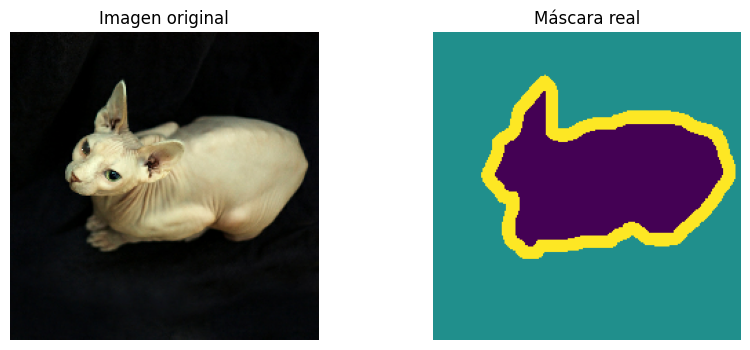

Clases presentes: [0 1 2]


In [ ]:
train_images = train_dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_images = test_dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

train_batches = (
    train_images
    .cache()
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .repeat()
    .prefetch(tf.data.AUTOTUNE)
)
test_batches = test_images.batch(BATCH_SIZE)

# Visualizar imagen original + máscara
def display(display_list, titles):
    plt.figure(figsize=(10, 4))
    for i, img in enumerate(display_list):
        plt.subplot(1, len(display_list), i + 1)
        plt.title(titles[i])
        plt.imshow(tf.keras.utils.array_to_img(img))
        plt.axis('off')
    plt.show()

for image, mask in train_images.take(1):
    display([image, mask], ["Imagen original", "Máscara real"])

print("Clases presentes:", np.unique(mask.numpy()))

In [ ]:
# 2) SELECCIÓN DE ARQUITECTURA: Segnet
def build_segnet(image_size=IMG_SIZE, num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=(image_size, image_size, 3))

    # ---------- ENCODER ----------
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=2)(x)  # 112x112

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=2)(x)  # 56x56

    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=2)(x)  # 28x28

    # ---------- DECODER ----------
    x = layers.UpSampling2D(size=2)(x)  # 56x56
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.UpSampling2D(size=2)(x)  # 112x112
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.UpSampling2D(size=2)(x)  # 224x224
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    outputs = layers.Conv2D(num_classes, 1, padding='same')(x)

    return Model(inputs, outputs, name="SegNet")

model = build_segnet()
model.summary()


Model: "SegNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_86 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_80          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_87 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_81          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_88 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_82          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_89 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_83          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_90 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_84          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_91 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_85          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_11 (UpSampling2D) │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_92 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_86          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_93 (Conv2D)              │ (None, 56, 56, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_87          │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │             

 Total params: 576,195 (2.20 MB)

 Trainable params: 574,659 (2.19 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [ ]:
# 3) COMPILACIÓN Y ENTRENAMIENTO
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

EPOCHS = 30
STEPS_PER_EPOCH = info.splits['train'].num_examples // BATCH_SIZE
VALIDATION_STEPS = info.splits['test'].num_examples // BATCH_SIZE

class EpochLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        print(f"Época {epoch + 1}/{EPOCHS} -> "
              f"loss: {logs['loss']:.4f}, accuracy: {logs['accuracy']:.4f}, "
              f"val_loss: {logs['val_loss']:.4f}, val_accuracy: {logs['val_accuracy']:.4f}")

history_Seg = model.fit(
    train_batches,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=test_batches,
    validation_steps=VALIDATION_STEPS,
    verbose=0,
    callbacks=[EpochLogger()]
)


Época 1/30 -> loss: 0.7425, accuracy: 0.6981, val_loss: 1.4948, val_accuracy: 0.5793
Época 2/30 -> loss: 0.5539, accuracy: 0.7758, val_loss: 0.6107, val_accuracy: 0.7468
Época 3/30 -> loss: 0.4927, accuracy: 0.8029, val_loss: 0.7885, val_accuracy: 0.7251
Época 4/30 -> loss: 0.4546, accuracy: 0.8191, val_loss: 0.6756, val_accuracy: 0.7578
Época 5/30 -> loss: 0.4367, accuracy: 0.8275, val_loss: 0.4818, val_accuracy: 0.8086
Época 6/30 -> loss: 0.4152, accuracy: 0.8364, val_loss: 0.4806, val_accuracy: 0.8172
Época 7/30 -> loss: 0.3917, accuracy: 0.8460, val_loss: 0.4401, val_accuracy: 0.8319
Época 8/30 -> loss: 0.3865, accuracy: 0.8477, val_loss: 0.4389, val_accuracy: 0.8324
Época 9/30 -> loss: 0.3762, accuracy: 0.8520, val_loss: 0.4023, val_accuracy: 0.8493
Época 10/30 -> loss: 0.3638, accuracy: 0.8576, val_loss: 0.4123, val_accuracy: 0.8404
Época 11/30 -> loss: 0.3506, accuracy: 0.8630, val_loss: 0.4138, val_accuracy: 0.8418
Época 12/30 -> loss: 0.3391, accuracy: 0.8673, val_loss: 0.3741

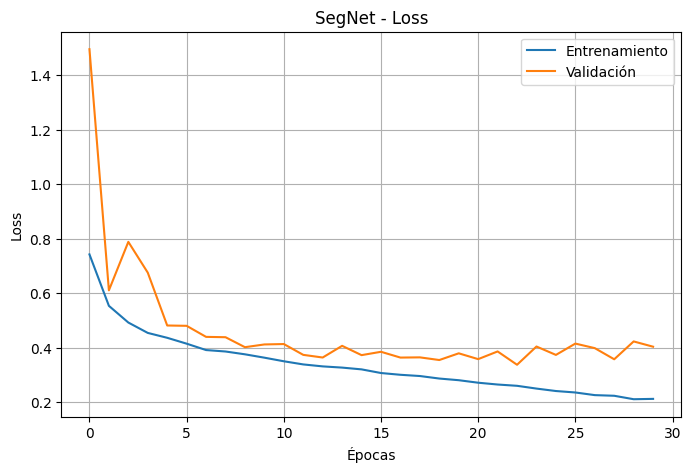

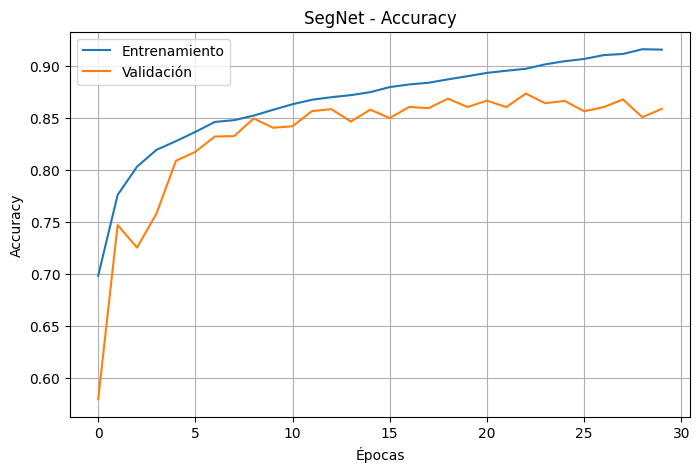

In [ ]:
# CURVA DE PÉRDIDA
plt.figure(figsize=(8,5))

plt.plot(history_Seg.history['loss'], label='Entrenamiento')
plt.plot(history_Seg.history['val_loss'], label='Validación')

plt.title("SegNet - Loss")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.show()

# Curva de entrenamiento
plt.figure(figsize=(8,5))

plt.plot(history_Seg.history['accuracy'], label='Entrenamiento')
plt.plot(history_Seg.history['val_accuracy'], label='Validación')

plt.title("SegNet - Accuracy")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


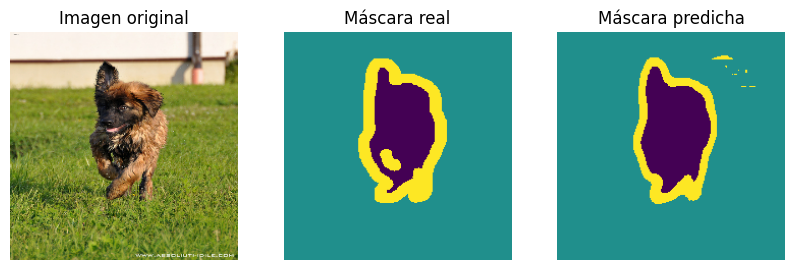

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


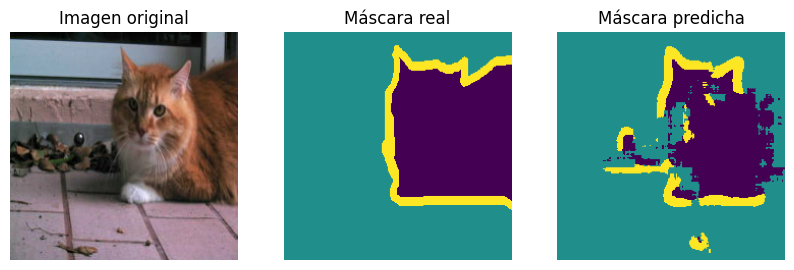

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


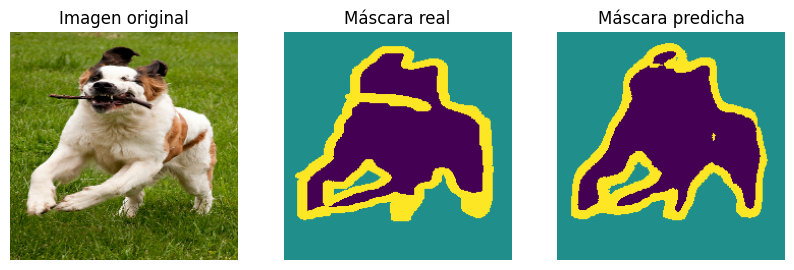

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


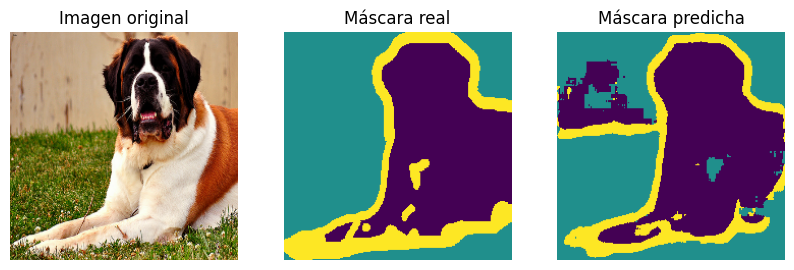

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


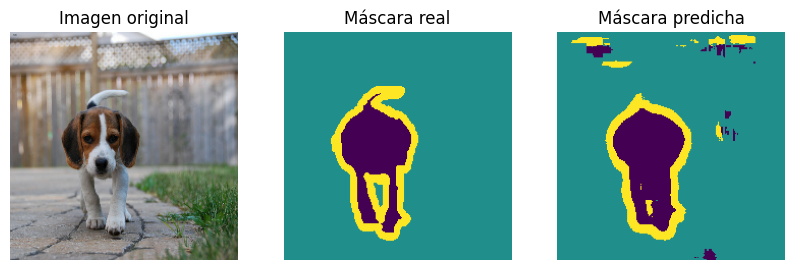

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


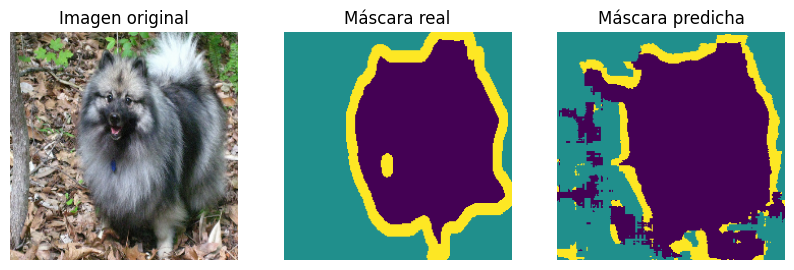

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


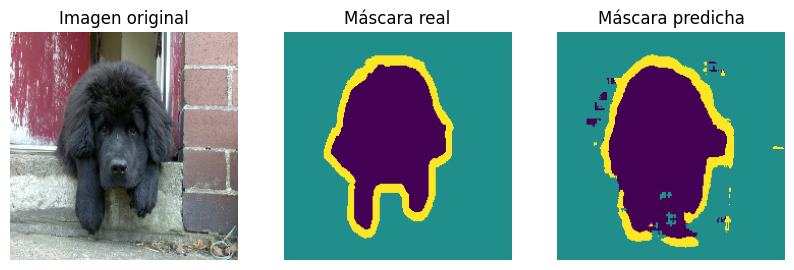

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


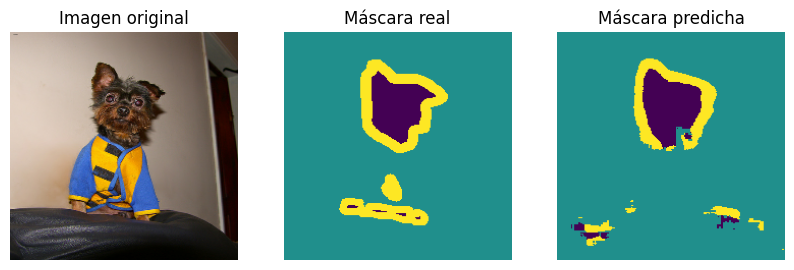

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


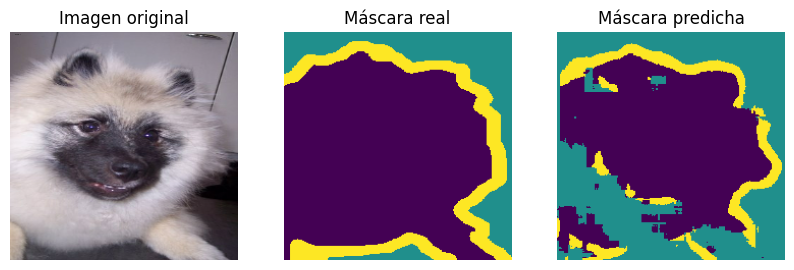

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


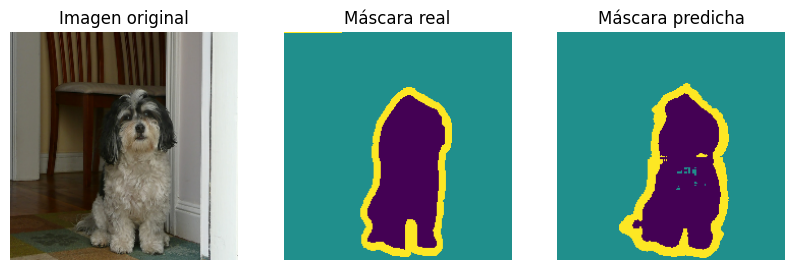

In [ ]:
# 4) SEGMENTACIÓN SOBRE IMÁGENES DE PRUEBA
def create_mask(pred_mask):
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    return pred_mask[0]

def show_predictions(dataset, num=3):
    for image, mask in dataset.take(num):
        pred_mask = model.predict(image[tf.newaxis, ...])
        display(
            [image, mask, create_mask(pred_mask)],
            ["Imagen original", "Máscara real", "Máscara predicha"]
        )

show_predictions(test_images, num=10)

In [ ]:
# 5) MÉTRICAS DE EVALUACIÓN (IoU)

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

y_true_total = []
y_pred_total = []

iou_metric = tf.keras.metrics.MeanIoU(num_classes=NUM_CLASSES)

for image, mask in test_batches.take(5):
    pred_mask = model.predict(image, verbose=0)
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = tf.expand_dims(pred_mask, axis=-1)

    iou_metric.update_state(mask, pred_mask)

    y_true_total.extend(tf.reshape(mask, [-1]).numpy())
    y_pred_total.extend(tf.reshape(pred_mask, [-1]).numpy())

print(f"\nAccuracy: {accuracy_score(y_true_total, y_pred_total):.2%}")
print(f"Mean IoU: {iou_metric.result().numpy():.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_true_total, y_pred_total, target_names=['Fondo', 'Borde', 'Mascota']))


Accuracy: 87.61%
Mean IoU: 0.6973

Reporte de clasificación:
              precision    recall  f1-score   support

       Fondo       0.88      0.87      0.87   1287883
       Borde       0.91      0.94      0.93   2256922
     Mascota       0.68      0.58      0.63    469275

    accuracy                           0.88   4014080
   macro avg       0.82      0.80      0.81   4014080
weighted avg       0.87      0.88      0.87   4014080



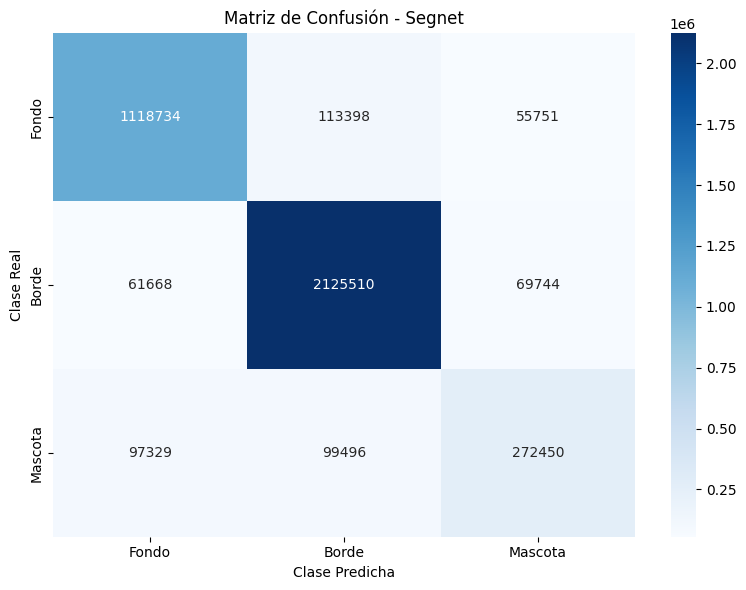

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_total, y_pred_total)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fondo', 'Borde', 'Mascota'],
    yticklabels=['Fondo', 'Borde', 'Mascota']
)

plt.title('Matriz de Confusión - Segnet')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.tight_layout()
plt.show()

# Yolo-Seg

In [ ]:
# 2) SELECCIÓN DE ARQUITECTURA: YOLO-Seg
def conv_bn_silu(x, filters, kernel_size=3, strides=1):
    x = layers.Conv2D(filters, kernel_size, strides=strides, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    return x

def csp_block(x, filters, num_blocks=2):
    shortcut = conv_bn_silu(x, filters // 2, kernel_size=1)
    main = conv_bn_silu(x, filters // 2, kernel_size=1)

    for _ in range(num_blocks):
        residual = main
        main = conv_bn_silu(main, filters // 2, kernel_size=3)
        main = conv_bn_silu(main, filters // 2, kernel_size=3)
        main = layers.Add()([main, residual])  # conexión residual

    x = layers.Concatenate()([main, shortcut])
    x = conv_bn_silu(x, filters, kernel_size=1)
    return x

def sppf_block(x, filters):
    x = conv_bn_silu(x, filters // 2, kernel_size=1)
    pool1 = layers.MaxPooling2D(pool_size=5, strides=1, padding='same')(x)
    pool2 = layers.MaxPooling2D(pool_size=5, strides=1, padding='same')(pool1)
    pool3 = layers.MaxPooling2D(pool_size=5, strides=1, padding='same')(pool2)
    x = layers.Concatenate()([x, pool1, pool2, pool3])
    x = conv_bn_silu(x, filters, kernel_size=1)
    return x

def build_yoloseg(image_size=IMG_SIZE, num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=(image_size, image_size, 3))
    x = conv_bn_silu(inputs, 32, kernel_size=3, strides=2)    # 112x112
    x = conv_bn_silu(x, 64, kernel_size=3, strides=2)         # 56x56
    x = csp_block(x, 64, num_blocks=1)

    x = conv_bn_silu(x, 128, kernel_size=3, strides=2)        # 28x28
    x = csp_block(x, 128, num_blocks=2)
    skip_128 = x  # se guarda para conexión tipo skip en el decoder

    x = conv_bn_silu(x, 256, kernel_size=3, strides=2)        # 14x14
    x = csp_block(x, 256, num_blocks=2)
    x = sppf_block(x, 256)

    x = layers.UpSampling2D(size=2)(x)                         # 28x28
    x = layers.Concatenate()([x, skip_128])
    x = csp_block(x, 128, num_blocks=1)

    x = layers.UpSampling2D(size=2)(x)                         # 56x56
    x = conv_bn_silu(x, 64, kernel_size=3)

    x = layers.UpSampling2D(size=2)(x)                         # 112x112
    x = conv_bn_silu(x, 32, kernel_size=3)

    x = layers.UpSampling2D(size=2)(x)                         # 224x224
    x = conv_bn_silu(x, 32, kernel_size=3)
    outputs = layers.Conv2D(num_classes, kernel_size=1, padding='same')(x)

    return Model(inputs, outputs, name="YOLO-Seg")

model = build_yoloseg()
model.summary()


Model: "YOLO-Seg"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 112, 112,  │        864 │ input_layer_7[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_69       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_99 (Conv2D)  │ (None, 56, 56,    │     18,432 │ activation_69[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_99[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_70       │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_101 (Conv2D) │ (None, 56, 56,    │      2,048 │ activation_70[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        128 │ conv2d_101[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_72       │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_102 (Conv2D) │ (None, 56, 56,    │      9,216 │ activation_72[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        128 │ conv2d_102[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_73       │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_103 (Conv2D) │ (None, 56, 56,    │      9,216 │ activation_73[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        128 │ conv2d_103[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_100 (Conv2D) │ (None, 56, 56,    │      2,048 │ activation_70[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_74       │ (None, 56, 56,    │          0 │ batch_normalizat

 Total params: 1,732,675 (6.61 MB)

 Trainable params: 1,726,467 (6.59 MB)

 Non-trainable params: 6,208 (24.25 KB)

In [ ]:

def dice_loss(y_true, y_pred, num_classes=NUM_CLASSES, smooth=1e-6):
    y_true_oh = tf.one_hot(tf.cast(tf.squeeze(y_true, axis=-1), tf.int32), num_classes)
    y_pred_soft = tf.nn.softmax(y_pred, axis=-1)

    intersection = tf.reduce_sum(y_true_oh * y_pred_soft, axis=[1, 2])
    union = tf.reduce_sum(y_true_oh, axis=[1, 2]) + tf.reduce_sum(y_pred_soft, axis=[1, 2])

    dice_coef = (2. * intersection + smooth) / (union + smooth)
    return 1 - tf.reduce_mean(dice_coef)
def combined_loss(y_true, y_pred):
    scce = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    ce_loss = scce(y_true, y_pred)
    d_loss = dice_loss(y_true, y_pred)
    return ce_loss + d_loss

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=combined_loss,
    metrics=['accuracy']
)

EPOCHS = 35
STEPS_PER_EPOCH = info.splits['train'].num_examples // BATCH_SIZE
VALIDATION_STEPS = info.splits['test'].num_examples // BATCH_SIZE

class EpochLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        print(f"Época {epoch + 1}/{EPOCHS} -> "
              f"loss: {logs['loss']:.4f}, accuracy: {logs['accuracy']:.4f}, "
              f"val_loss: {logs['val_loss']:.4f}, val_accuracy: {logs['val_accuracy']:.4f}")

history = model.fit(
    train_batches,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=test_batches,
    validation_steps=VALIDATION_STEPS,
    verbose=0,
    callbacks=[EpochLogger()]
)

Época 1/35 -> loss: 1.1507, accuracy: 0.7269, val_loss: 1.3073, val_accuracy: 0.7201
Época 2/35 -> loss: 0.8201, accuracy: 0.8179, val_loss: 0.8299, val_accuracy: 0.8167
Época 3/35 -> loss: 0.7115, accuracy: 0.8457, val_loss: 0.8825, val_accuracy: 0.8038
Época 4/35 -> loss: 0.6416, accuracy: 0.8626, val_loss: 0.7439, val_accuracy: 0.8427
Época 5/35 -> loss: 0.5917, accuracy: 0.8754, val_loss: 0.7283, val_accuracy: 0.8360
Época 6/35 -> loss: 0.5514, accuracy: 0.8845, val_loss: 0.6029, val_accuracy: 0.8736
Época 7/35 -> loss: 0.5190, accuracy: 0.8918, val_loss: 0.7515, val_accuracy: 0.8469
Época 8/35 -> loss: 0.4996, accuracy: 0.8965, val_loss: 0.5951, val_accuracy: 0.8725
Época 9/35 -> loss: 0.4700, accuracy: 0.9035, val_loss: 0.6486, val_accuracy: 0.8669
Época 10/35 -> loss: 0.4458, accuracy: 0.9091, val_loss: 0.6291, val_accuracy: 0.8710
Época 11/35 -> loss: 0.4381, accuracy: 0.9105, val_loss: 0.6092, val_accuracy: 0.8793
Época 12/35 -> loss: 0.4165, accuracy: 0.9153, val_loss: 0.5838

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


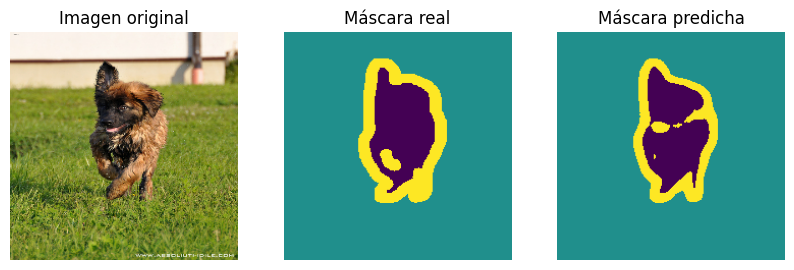

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


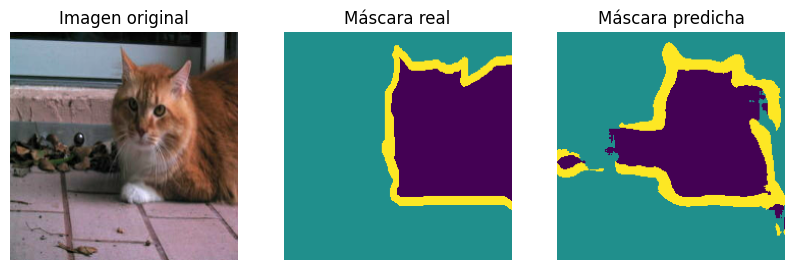

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


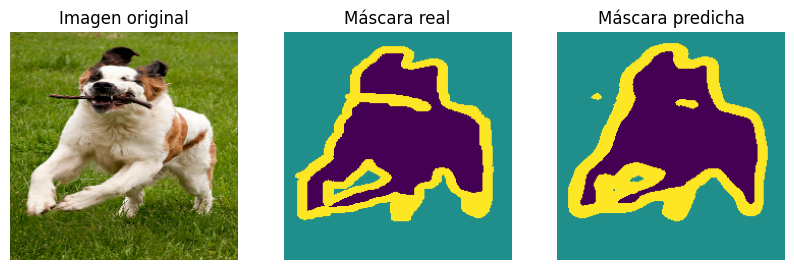

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


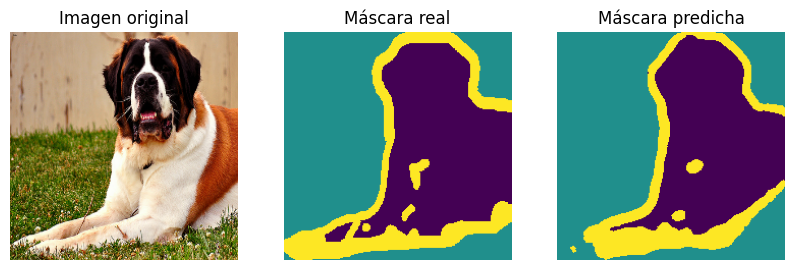

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


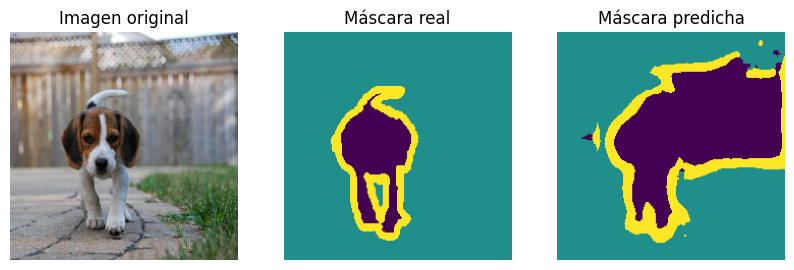

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


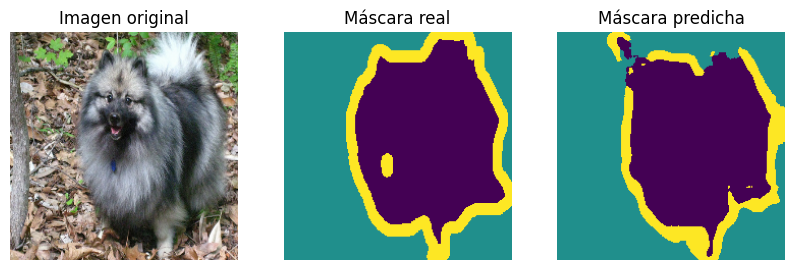

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


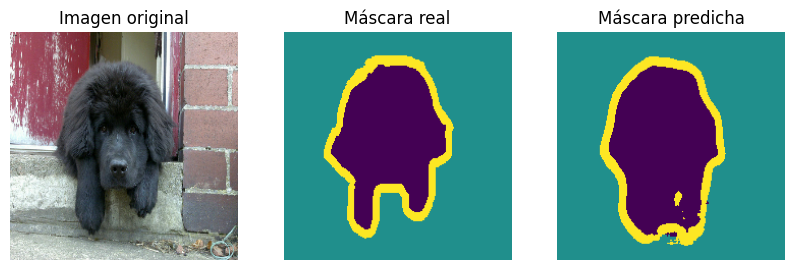

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


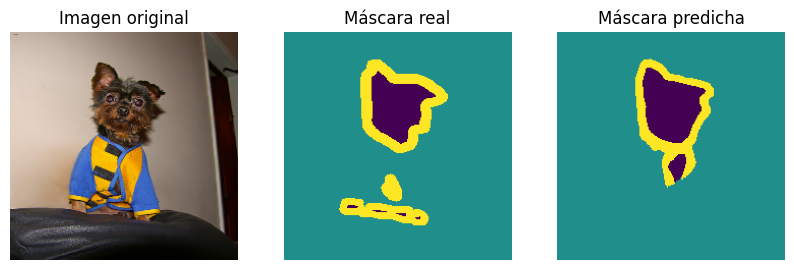

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


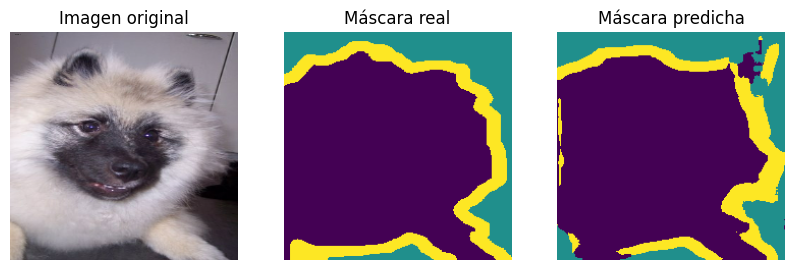

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


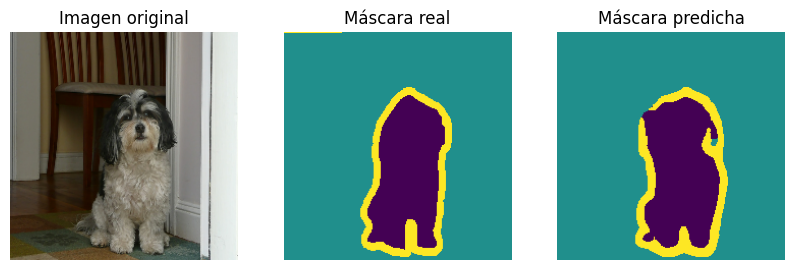

In [ ]:
# 4) SEGMENTACIÓN SOBRE IMÁGENES DE PRUEBA
def create_mask(pred_mask):
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    return pred_mask[0]

def show_predictions(dataset, num=3):
    for image, mask in dataset.take(num):
        pred_mask = model.predict(image[tf.newaxis, ...])
        display(
            [image, mask, create_mask(pred_mask)],
            ["Imagen original", "Máscara real", "Máscara predicha"]
        )

show_predictions(test_images, num=10)

In [ ]:
# 5) MÉTRICAS DE EVALUACIÓN
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

y_true_total = []
y_pred_total = []

iou_metric = tf.keras.metrics.MeanIoU(num_classes=NUM_CLASSES)

for image, mask in test_batches.take(5):
    pred_mask = model.predict(image, verbose=0)
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = tf.expand_dims(pred_mask, axis=-1)

    iou_metric.update_state(mask, pred_mask)

    y_true_total.extend(tf.reshape(mask, [-1]).numpy())
    y_pred_total.extend(tf.reshape(pred_mask, [-1]).numpy())

print(f"\nAccuracy: {accuracy_score(y_true_total, y_pred_total):.2%}")
print(f"Mean IoU: {iou_metric.result().numpy():.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_true_total, y_pred_total, target_names=['Fondo', 'Borde', 'Mascota']))


Accuracy: 89.84%
Mean IoU: 0.7384

Reporte de clasificación:
              precision    recall  f1-score   support

       Fondo       0.89      0.92      0.91   1287883
       Borde       0.95      0.94      0.94   2256922
     Mascota       0.67      0.65      0.66    469275

    accuracy                           0.90   4014080
   macro avg       0.84      0.84      0.84   4014080
weighted avg       0.90      0.90      0.90   4014080



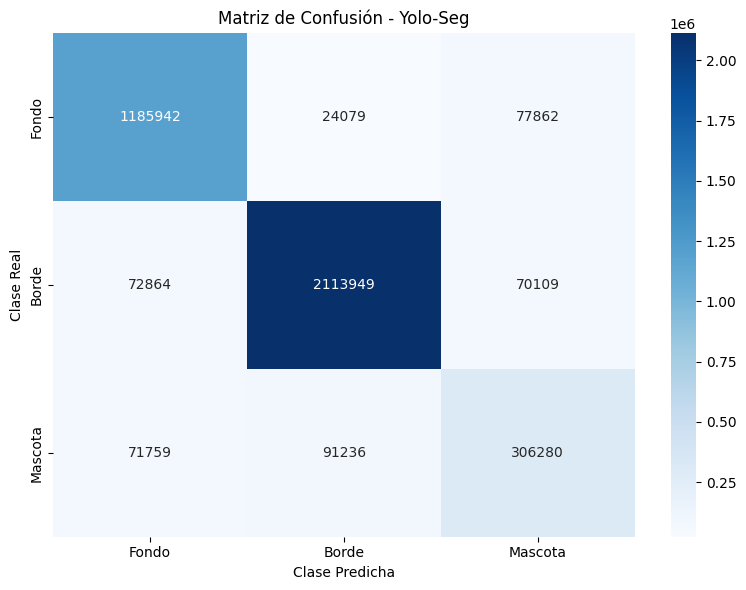

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_total, y_pred_total)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fondo', 'Borde', 'Mascota'],
    yticklabels=['Fondo', 'Borde', 'Mascota']
)

plt.title('Matriz de Confusión - Yolo-Seg')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.tight_layout()
plt.show()

## Análisis de resultados

### ¿Qué arquitectura de segmentación implementaron y por qué la seleccionaron?

Se implementó la arquitectura **SegNet**, un modelo de segmentación semántica basado en una estructura **encoder-decoder**.

Fue seleccionada porque permite realizar clasificación a nivel de píxel, mantiene información espacial mediante las operaciones de pooling y unpooling, y representa una arquitectura eficiente para establecer un modelo base de comparación en tareas de segmentación.

---

### ¿Qué fortalezas observaron durante la segmentación?

- El modelo logró generar máscaras semánticas a nivel de píxel, identificando correctamente las regiones principales de las imágenes.
- Presentó buen desempeño en la separación entre objeto y fondo.
- La arquitectura mostró capacidad para aprender características visuales relevantes de las mascotas.
- Las métricas obtenidas permitieron evaluar la calidad de la segmentación mediante Accuracy, Mean IoU y Dice Coefficient.

---

### ¿Qué limitaciones encuentran en el modelo utilizado?

- Puede presentar dificultades en regiones pequeñas o con detalles finos debido a la reducción de resolución durante el encoder.
- El desempeño puede disminuir cuando existen fondos complejos, oclusiones o variaciones importantes en la apariencia del objeto.
- Existe posibilidad de sobreajuste si el modelo aprende características específicas del conjunto de entrenamiento.
- La calidad de la segmentación depende directamente de la precisión de las máscaras originales del dataset.

---

### ¿Qué variables afectaron el desempeño del modelo?

Los principales factores que pueden influir en la segmentación son:

- **Iluminación:** cambios de brillo, sombras o baja iluminación.
- **Fondo:** texturas complejas o colores similares al objeto.
- **Oclusiones:** objetos que cubren parcialmente la mascota.
- **Variación visual:** diferentes razas, tamaños y posiciones.
- **Resolución:** pérdida de detalles al reducir las imágenes para el entrenamiento.

---

### ¿En qué aplicaciones reales sería adecuada esta arquitectura?

SegNet puede aplicarse en:

- Sistemas de análisis y reconocimiento de animales.
- Realidad aumentada y efectos visuales.
- Robótica y navegación inteligente.
- Inspección visual automatizada.
- Análisis de imágenes médicas o biológicas con datasets especializados.

---

### ¿Qué mejoras realizarían con más tiempo de desarrollo?

Como mejoras futuras se propone:

- Aplicar técnicas de **Data Augmentation** para aumentar la variabilidad del entrenamiento.
- Utilizar modelos preentrenados mediante **Transfer Learning** para mejorar la extracción de características.
- Optimizar hiperparámetros como tasa de aprendizaje y número de épocas.
- Implementar funciones de pérdida avanzadas como **Dice Loss o Focal Loss** para mejorar la segmentación de clases menos representadas.
- Comparar SegNet con arquitecturas más modernas como **U-Net o DeepLabV3+**.
- Realizar análisis de errores para identificar casos donde el modelo falla.

# Preguntas de control

* ¿Cuál es la diferencia entre clasificación, detección y segmentación de imágenes?

La clasificación de imágenes consiste en asignar una única etiqueta a toda la imagen, indicando qué objeto o categoría contiene. La detección de objetos, además de identificar la clase, localiza cada objeto mediante un cuadro delimitador (bounding box). En cambio, la segmentación realiza una clasificación a nivel de píxel, generando una máscara que delimita con precisión cada región de la imagen. En el código desarrollado se implementa segmentación, ya que el modelo predice una máscara para cada imagen del conjunto de datos.

* ¿Qué diferencia existe entre segmentación semántica y segmentación de instancias?

La segmentación semántica asigna una clase a cada píxel, pero no distingue entre diferentes objetos de la misma categoría. Por ejemplo, si existen dos perros en una imagen, ambos serán etiquetados como "perro". La segmentación de instancias, además de clasificar los píxeles, diferencia cada objeto individual, por lo que cada perro tendría su propia máscara independiente.

* ¿Cuál es la función del encoder y del decoder en una arquitectura de segmentación?

El encoder tiene la función de extraer las características más importantes de la imagen mediante capas convolucionales y operaciones de reducción de tamaño, permitiendo que el modelo aprenda información relevante. Posteriormente, el decoder reconstruye la resolución original utilizando esas características para generar la máscara de segmentación, asignando una clase a cada píxel de la imagen.

* ¿Qué ventajas ofrecen las conexiones Skip Connections en arquitecturas como U-Net?

Las Skip Connections permiten transmitir directamente la información de las primeras capas del encoder hacia el decoder. Gracias a ello, se conserva mejor la información espacial y los detalles finos de la imagen, lo que mejora la precisión en los bordes y la segmentación de objetos pequeños. Además, facilitan el entrenamiento de redes profundas al reducir la pérdida de información durante el proceso de codificación.

* ¿Qué factores pueden afectar la calidad de una segmentación?

La calidad de la segmentación puede verse afectada por factores como una iluminación deficiente, fondos complejos, oclusiones parciales de los objetos, baja resolución de las imágenes, ruido, variaciones en la escala o la orientación de los objetos y un conjunto de entrenamiento poco diverso. También influyen la arquitectura seleccionada, los hiperparámetros del entrenamiento y la cantidad de datos disponibles para entrenar el modelo.

* ¿Qué métricas pueden emplearse para evaluar un modelo de segmentación y qué información proporciona cada una?

Se utilizaron métricas como la exactitud (Accuracy), el índice de intersección sobre unión (IoU o Intersection over Union), la matriz de confusión y el reporte de clasificación. Se indica el porcentaje de píxeles correctamente clasificados, aunque puede resultar poco representativa cuando existen clases desbalanceadas. La métrica IoU mide el grado de coincidencia entre la máscara predicha y la máscara real, siendo una de las más utilizadas para evaluar segmentación. La matriz de confusión muestra los aciertos y errores entre las clases, mientras que el reporte de clasificación proporciona métricas como precisión, recall y F1-score para analizar el desempeño del modelo en cada categoría.

# Conclusiones

* Los resultados muestran que YOLO-Seg superó a SegNet en las métricas de evaluación, alcanzando un Accuracy de 89.84% y un Mean IoU de 0.7384%, mientras que SegNet obtuvo 87.61% y 0.6973%, respectivamente. Asimismo, YOLO-Seg logró un F1-score de 0.66 para la clase Mascota, superior al 0.63 obtenido por SegNet. Esta diferencia también se aprecia visualmente en las imágenes de prueba, donde las máscaras generadas por YOLO-Seg presentan una mayor correspondencia con las máscaras reales, conservando mejor la forma general de los animales y produciendo menos regiones faltantes o segmentaciones incompletas. En conjunto, estos resultados presentan una ligera mejora en la capacidad de YOLO-Seg para representar con precisión los objetos presentes en el conjunto de datos.

* SegNet obtuvo un buen rendimiento en las clases Fondo y Borde, presentó mayores dificultades para segmentar correctamente la clase Mascota, reflejadas en un Recall de 0.58, inferior al 0.65 alcanzado por YOLO-Seg. Esto indica que una mayor cantidad de píxeles pertenecientes a la mascota fueron clasificados incorrectamente como fondo o borde. Esto se observa en las predicciones realizadas, ya que las máscaras producidas por SegNet presentan pérdidas de información en el interior del objeto y contornos menos definidos. Estas limitaciones pueden atribuirse a su arquitectura encoder–decoder, que utiliza operaciones de UpSampling para reconstruir la resolución espacial y no incorpora mecanismos de extracción y fusión multiescala como los presentes en YOLO-Seg, reduciendo así su capacidad para preservar detalles finos y segmentar objetos con formas complejas.